# Sentiment Analysis — Naive Bayes Baseline (Sentiment140)

Binary classification baseline on 1.6M tweets.
Labels: `0` = negative, `4` = positive → mapped to `negative` / `positive`.

This notebook mirrors the architecture of `NaiveBayes.ipynb` (SST) to produce a
comparable baseline before moving to transformer-based models.

## 1. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.naive_bayes import ComplementNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')
print('All imports successful.')

All imports successful.


## 2. Load Dataset

Sentiment140 CSV has no header row. Column order:
`target, id, date, flag, user, text`

In [13]:
DATASET_PATH = 'training.1600000.processed.noemoticon.csv'

df = pd.read_csv(
    DATASET_PATH,
    encoding='latin-1',
    header=None,
    names=['target', 'id', 'date', 'flag', 'user', 'text']
)

print(f'Total samples: {len(df):,}')
print(f'Label distribution:')
print(df['target'].value_counts())
df[['target', 'text']].head(5)

Total samples: 1,600,000
Label distribution:
target
0    800000
4    800000
Name: count, dtype: int64


,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


## 3. Map Labels & Clean Text

Sentiment140 labels: `0` → `negative`, `4` → `positive`.

Tweet-specific cleaning:
- Remove URLs, @mentions, and `#` from hashtags (keep the word)
- Expand common contractions (`n't` → `not`)
- Collapse repeated characters (`loooove` → `loove` — keeps emphasis signal)
- Strip non-ASCII and extra whitespace

In [14]:
# Map numeric labels
df['label'] = df['target'].map({0: 'negative', 4: 'positive'})

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+',       '',    text)  # URLs
    text = re.sub(r'@\w+',                 '',    text)  # @mentions
    text = re.sub(r'#(\w+)',               r'\1', text)  # hashtags -> word
    text = re.sub(r"n't\b",               ' not', text)  # contractions
    text = re.sub(r'(.)\1{2,}',            r'\1\1', text) # repeated chars
    text = re.sub(r'[^\x00-\x7F]+',        '',    text)  # non-ASCII
    text = re.sub(r'\s+',                  ' ',   text).strip().lower()
    return text

df['text_clean'] = df['text'].apply(clean_tweet)

# Drop empty rows produced by cleaning
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)

print(f'Samples after cleaning: {len(df):,}')
print(f'\nClass distribution:')
print(df['label'].value_counts())
print(f'\nSample cleaned tweets:')
print(df[['text', 'text_clean', 'label']].sample(5, random_state=42).to_string(index=False))

Samples after cleaning: 1,597,119

Class distribution:
label
positive    798642
negative    798477
Name: count, dtype: int64

Sample cleaned tweets:
                                                                                                                  text                                                                                            text_clean    label
@alicesteaparty so, just name a night this week (except Thursday) and I am there. And if you need a pin I gotcha one.  so, just name a night this week (except thursday) and i am there. and if you need a pin i gotcha one. positive
                                 Nearly passed out on the bus Yesterday, thank God I don't have to get up on Saturday                  nearly passed out on the bus yesterday, thank god i do not have to get up on saturday positive
                                                                            Makazee buat obatnya,buat perhatiannya!!!                                            

## 4. Subsample for Baseline

1.6M tweets is large for a Naive Bayes baseline — TF-IDF fitting on the full corpus
uses significant memory. A stratified subsample of 200k (100k per class) gives
stable results while keeping runtimes reasonable.

Set `USE_FULL_DATASET = True` to train on all 1.6M tweets if memory allows.

In [15]:
USE_FULL_DATASET = False
SAMPLE_PER_CLASS = 100_000

if not USE_FULL_DATASET:
    neg = df[df['label'] == 'negative'].sample(n=SAMPLE_PER_CLASS, random_state=42)
    pos = df[df['label'] == 'positive'].sample(n=SAMPLE_PER_CLASS, random_state=42)
    df_work = pd.concat([neg, pos]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'Working with {len(df_work):,} samples ({SAMPLE_PER_CLASS:,} per class)')
else:
    df_work = df.copy()
    print(f'Working with full dataset: {len(df_work):,} samples')

print(df_work['label'].value_counts())

Working with 200,000 samples (100,000 per class)
label
positive    100000
negative    100000
Name: count, dtype: int64


## 5. Train / Dev / Test Split

Sentiment140 has no official split file. Stratified random split: 70% train, 10% dev, 20% test.

In [16]:
X = df_work['text_clean']
y = df_work['label']

# First split off test set
X_traindev, X_test, y_traindev, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split remainder into train / dev
X_train, X_dev, y_train, y_dev = train_test_split(
    X_traindev, y_traindev, test_size=0.125, random_state=42, stratify=y_traindev
    # 0.125 of 0.8 = 0.1 of total
)

print(f'Train: {len(X_train):,}  |  Dev: {len(X_dev):,}  |  Test: {len(X_test):,}')
print(f'\nTrain class distribution:')
print(y_train.value_counts())

Train: 140,000  |  Dev: 20,000  |  Test: 40,000

Train class distribution:
label
positive    70000
negative    70000
Name: count, dtype: int64


## 6. Vectorise & Train

In [17]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    max_features=150_000   # cap vocabulary — tweets are noisy; rare tokens add noise
)

X_train_vec = vectorizer.fit_transform(X_train)
X_dev_vec   = vectorizer.transform(X_dev)
X_test_vec  = vectorizer.transform(X_test)

model = ComplementNB(alpha=0.3)
model.fit(X_train_vec, y_train)

print(f'Vocabulary size: {len(vectorizer.vocabulary_):,}')
print('Model trained.')

Vocabulary size: 95,857
Model trained.


## 7. Evaluate on Dev Set

In [18]:
y_dev_pred = model.predict(X_dev_vec)

print(f'Dev Accuracy: {accuracy_score(y_dev, y_dev_pred):.4f}\n')
print(classification_report(y_dev, y_dev_pred, target_names=['negative', 'positive']))

Dev Accuracy: 0.7479

              precision    recall  f1-score   support

    negative       0.74      0.76      0.75     10000
    positive       0.75      0.74      0.75     10000

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000



## 8. Final Evaluation on Test Set

Run once after all tuning is complete.

Test Accuracy: 0.7467

              precision    recall  f1-score   support

    negative       0.74      0.75      0.75     20000
    positive       0.75      0.74      0.75     20000

    accuracy                           0.75     40000
   macro avg       0.75      0.75      0.75     40000
weighted avg       0.75      0.75      0.75     40000



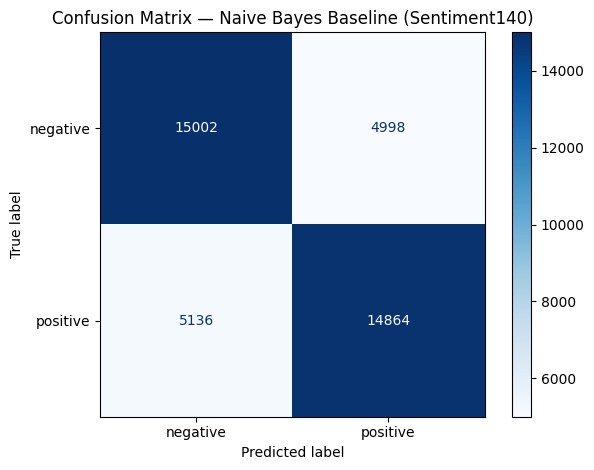

In [19]:
y_test_pred = model.predict(X_test_vec)

print(f'Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}\n')
print(classification_report(y_test, y_test_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_test, y_test_pred, labels=['negative', 'positive'])
ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive']).plot(cmap='Blues')
plt.title('Confusion Matrix — Naive Bayes Baseline (Sentiment140)')
plt.tight_layout()
plt.show()

## 9. Top Discriminative Features per Class

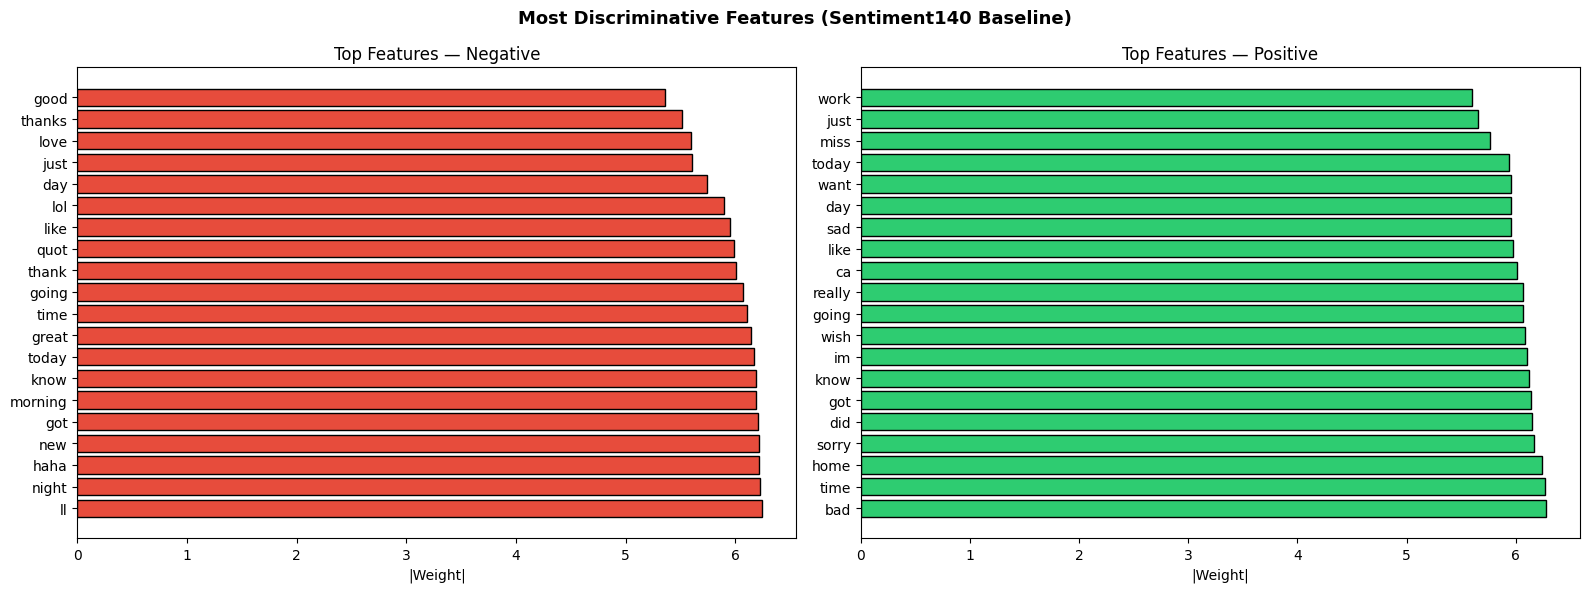

In [20]:
def top_features(model, vectorizer, class_label, n=20):
    class_idx = list(model.classes_).index(class_label)
    weights   = model.feature_log_prob_[class_idx]
    top_idx   = np.argsort(weights)[:n]  # lowest = most discriminative for ComplementNB
    features  = np.array(vectorizer.get_feature_names_out())
    return list(zip(features[top_idx], weights[top_idx]))

colors = {'negative': '#e74c3c', 'positive': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cls in zip(axes, ['negative', 'positive']):
    feats = top_features(model, vectorizer, cls, n=20)
    words, scores = zip(*feats)
    ax.barh(words[::-1], np.abs(scores[::-1]), color=colors[cls], edgecolor='black')
    ax.set_title(f'Top Features — {cls.capitalize()}')
    ax.set_xlabel('|Weight|')

plt.suptitle('Most Discriminative Features (Sentiment140 Baseline)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Baseline Summary

Records the key numbers from this run for comparison with transformer experiments.

In [21]:
from sklearn.metrics import f1_score

summary = {
    'Model':            'ComplementNB',
    'Dataset':          'Sentiment140',
    'Training samples': len(X_train),
    'Test samples':     len(X_test),
    'Vocabulary size':  len(vectorizer.vocabulary_),
    'Dev accuracy':     round(accuracy_score(y_dev, y_dev_pred), 4),
    'Test accuracy':    round(accuracy_score(y_test, y_test_pred), 4),
    'Test F1 (macro)':  round(f1_score(y_test, y_test_pred, average='macro'), 4),
    'Test F1 (negative)': round(f1_score(y_test, y_test_pred, pos_label='negative', average='binary'), 4),
    'Test F1 (positive)': round(f1_score(y_test, y_test_pred, pos_label='positive', average='binary'), 4),
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
print('=== BASELINE RESULTS ===')
print(summary_df.to_string(index=False))

# Save for later comparison
summary_df.to_csv('baseline_results.csv', index=False)
print('\nSaved to baseline_results.csv')

=== BASELINE RESULTS ===
            Metric        Value
             Model ComplementNB
           Dataset Sentiment140
  Training samples       140000
      Test samples        40000
   Vocabulary size        95857
      Dev accuracy       0.7479
     Test accuracy       0.7467
   Test F1 (macro)       0.7466
Test F1 (negative)       0.7475
Test F1 (positive)       0.7458

Saved to baseline_results.csv


## 11. Predict on Custom Tweets

In [22]:
custom_tweets = [
    "just got the best coffee of my life ☕ absolutely love this place!",
    "my flight got cancelled again. third time this month. done with this airline",
    "can't believe how good this new album is, been on repeat all day",
    "so tired of this weather, everything is grey and miserable",
    "heading to the gym, feeling motivated today"
]

custom_clean = [clean_tweet(t) for t in custom_tweets]
custom_vec   = vectorizer.transform(custom_clean)
predictions  = model.predict(custom_vec)
proba        = model.predict_proba(custom_vec)

results = pd.DataFrame({
    'Tweet':       custom_tweets,
    'Predicted':   predictions,
    'P(negative)': proba[:, list(model.classes_).index('negative')].round(3),
    'P(positive)': proba[:, list(model.classes_).index('positive')].round(3),
})
results

,Tweet,Predicted,P(negative),P(positive)
0,just got the best coffee of my life ☕ absolute...,positive,0.082,0.918
1,my flight got cancelled again. third time this...,negative,0.959,0.041
2,"can't believe how good this new album is, been...",positive,0.269,0.731
3,"so tired of this weather, everything is grey a...",negative,0.890,0.110
4,"heading to the gym, feeling motivated today",negative,0.544,0.456
